In [1]:
import pymc as pm
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import arviz as az
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("HealthyRideIvyWalnut.csv")

In [2]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
months = [ 'July', 'August', 'September']

# Encode day and month as integer indices
day_encoder = LabelEncoder()
day_encoder.classes_ = np.array(days)  # Ensure consistent ordering
df['day_idx'] = day_encoder.transform(df['day'])

month_encoder = LabelEncoder()
month_encoder.classes_ = np.array(months)  # Ensure consistent ordering
df['month_idx'] = month_encoder.transform(df['month'])

# Response variable
y = df['trips'].values

# Verify data
print("Unique days:", df['day'].unique())
print("Unique months:", df['month'].unique())
print("Trip counts summary:", df['trips'].describe())


Unique days: ['Sunday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Monday']
Unique months: ['July' 'August' 'September']
Trip counts summary: count    91.000000
mean      2.505495
std       2.544596
min       0.000000
25%       1.000000
50%       2.000000
75%       4.000000
max      15.000000
Name: trips, dtype: float64


In [3]:
# Define the Bayesian Poisson regression model
with pm.Model() as model:
    # Data
    day_data = df['day_idx']
    month_data = df['month_idx']
    y_data = y

    # Priors for day and month effects
    day_effects = pm.Normal("day_effects", mu=0, sigma=0.5, shape=len(days))  # 7 days
    month_effects = pm.Normal("month_effects", mu=0, sigma=0.5, shape=len(months))  # 3 months
    intercept = pm.Normal("intercept", mu=np.log(y.mean() + 1e-6), sigma=0.5)  # Avoid log(0)

    # Linear combination (log-rate)
    log_rate = intercept + day_effects[day_data] + month_effects[month_data]

    # Poisson likelihood
    y_obs = pm.Poisson("y_obs", mu=pm.math.exp(log_rate), observed=y_data)

    # Sample from the posterior
    trace = pm.sample(1000, tune=1000, return_inferencedata=True, random_seed=42, init="jitter+adapt_diag")

# Summarize the posterior
summary = az.summary(trace, var_names=["intercept", "day_effects", "month_effects"])
# Map indices back to names for interpretability
summary.index = ['intercept'] + [f"day_{days[i]}" for i in range(len(days))] + [f"month_{months[i]}" for i in range(len(months))]
print(summary)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [day_effects, month_effects, intercept]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept        0.831  0.287   0.292    1.383      0.008    0.005    1429.0   
day_Monday      -0.519  0.270  -1.042   -0.034      0.006    0.004    2060.0   
day_Tuesday     -0.425  0.261  -0.905    0.077      0.006    0.004    2098.0   
day_Wednesday   -0.377  0.258  -0.860    0.114      0.006    0.004    2187.0   
day_Thursday    -0.215  0.251  -0.658    0.277      0.005    0.004    2097.0   
day_Friday       0.228  0.231  -0.198    0.665      0.006    0.004    1674.0   
day_Saturday     0.709  0.221   0.306    1.132      0.006    0.004    1603.0   
day_Sunday       0.515  0.230   0.082    0.941      0.006    0.004    1745.0   
month_July       0.127  0.276  -0.397    0.660      0.007    0.005    1616.0   
month_August    -0.041  0.270  -0.541    0.479      0.007    0.005    1632.0   
month_September -0.186  0.278  -0.679    0.384      0.007    0.005    1611.0   

                 ess_tail  r_hat  
inte

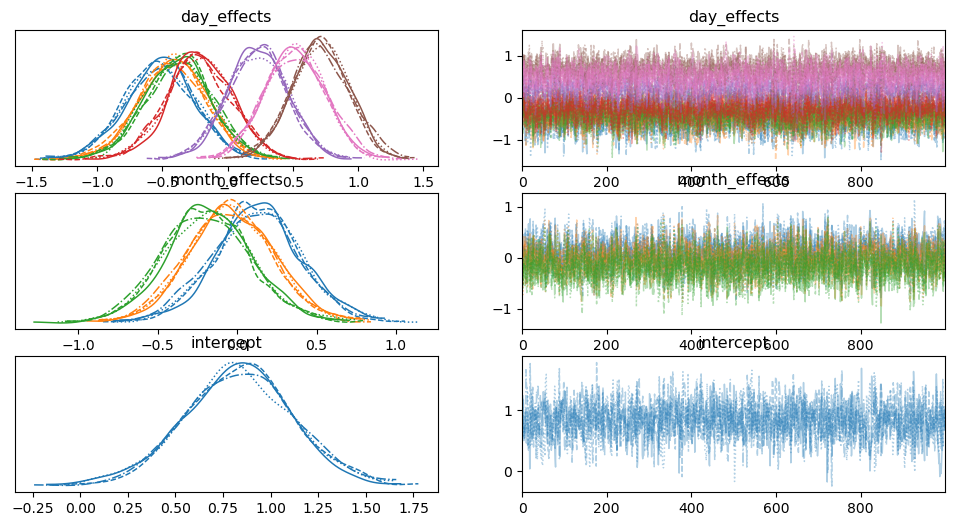

In [4]:
az.plot_trace(trace)
plt.show()